# Set up

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [27]:
# Package import
import pandas as pd
#%pip install openpyxl
import re
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.feature_extraction.text import TfidfVectorizer
from wordcloud import WordCloud
import umap
from sentence_transformers import SentenceTransformer
from sklearn.preprocessing import LabelEncoder
from transformers import AutoTokenizer, AutoModelForSequenceClassification
from transformers import pipeline
import torch
import numpy as np
import random
from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score, f1_score, log_loss,
    confusion_matrix, ConfusionMatrixDisplay, classification_report
)


In [4]:
# Access to data in google drive
data = pd.read_excel("/content/drive/MyDrive/TES/20250602_Anfragen_Sample.xlsx", engine="openpyxl")
#data = pd.read_excel("/content/drive/MyDrive/Colab Notebooks/20250602_Anfragen_Sample.xlsx", engine="openpyxl")

display(data.head())

# Select & Rename columns
df = data[['Unterkategorie2', 'Kundenanfrage']].rename(columns={
    'Unterkategorie2': 'label',
    'Kundenanfrage': 'email'
})

# Dataset ready
print(df)

,Nr.,Hauptkategorie,Unterkategorie1,Unterkategorie2,Kundenanfrage,Weiterleitung
0,1,Online-Banking,App,TAN-Verfahren,"Guten Tag Herr Wagner, ich habe heute Morgen v...",GKS
1,2,Online-Banking,App,TAN-Verfahren,"Guten Tag Frau Schubert, seit gestern reagiert...",GKS
2,3,Online-Banking,App,TAN-Verfahren,"Guten Tag Frau Schneider, beim Login ins Onlin...",GKS
3,4,Online-Banking,App,TAN-Verfahren,"Liebes Team der Sparkasse, ich habe vor kurzem...",GKS
4,5,Online-Banking,App,TAN-Verfahren,"Guten Tag Herr Wagner, leider funktioniert mei...",GKS


              label                                              email
0     TAN-Verfahren  Guten Tag Herr Wagner, ich habe heute Morgen v...
1     TAN-Verfahren  Guten Tag Frau Schubert, seit gestern reagiert...
2     TAN-Verfahren  Guten Tag Frau Schneider, beim Login ins Onlin...
3     TAN-Verfahren  Liebes Team der Sparkasse, ich habe vor kurzem...
4     TAN-Verfahren  Guten Tag Herr Wagner, leider funktioniert mei...
..              ...                                                ...
244  Namensänderung  Guten Tag Frau Schneider, mein Name war Paul F...
245  Namensänderung  Guten Tag Frau Schubert, mein früherer Name la...
246  Namensänderung  Guten Tag Frau Schneider, mein bisheriger Name...
247  Namensänderung  Guten Tag Herr Becker, bislang war ich bei Ihn...
248  Namensänderung  Guten Tag Herr Becker, mein früherer Name war ...

[249 rows x 2 columns]


# 1. Data preprocessing and Feature engineering

To remove the greeting and only keep pure text (remove noises for model)

In [5]:
def clean_email(text):
    text = re.sub(r'^.*?,', '', text)
    text = re.sub(r'(Mit freundlichen Grüßen|Viele Grüße|Liebe Grüße|Beste Grüße|Herzliche Grüße|Freundliche Grüße|Grüße|MfG)[\s\S]+', '', text, flags=re.IGNORECASE)
    return text.strip()

df["email_cleaned"] = df["email"].apply(clean_email)

# Examples
df["email_cleaned"].head(10).to_list()

['ich habe heute Morgen versucht, mich wie gewohnt in mein Online-Banking einzuloggen. Leider lässt sich meine TAN-App nicht öffnen – es erscheint nur ein weißer Bildschirm. Ich bin verunsichert, da ich dringend eine Überweisung tätigen muss. Können Sie bitte prüfen, woran das liegt oder mir kurzfristig eine Alternative anbieten?',
 'seit gestern reagiert meine TAN-App nicht mehr. Ich bekomme beim Start lediglich eine Fehlermeldung angezeigt und komme somit nicht weiter. Da ich beruflich auf regelmäßige Zahlungen angewiesen bin, wäre ich für eine schnelle Lösung dankbar.',
 'beim Login ins Online-Banking werde ich wie gewohnt zur TAN-Eingabe aufgefordert. Allerdings erzeugt meine App keine gültige TAN mehr – sie scheint abgestürzt zu sein. Ich kann daher keine Transaktionen durchführen. Was kann ich in diesem Fall tun?',
 'ich habe vor kurzem mein Smartphone aktualisiert, und seither funktioniert die TAN-App nicht mehr. Es erscheint immer ein Fehler beim Öffnen. Ich bin momentan komple

Define Stopwords manually

In [6]:
german_stopwords = [
    "aber", "alle", "allem", "allen", "aller", "alles", "als", "also", "am", "an", "ander", "andere", "anderem",
    "anderen", "anderer", "anderes", "anderm", "andern", "anderr", "anders", "auch", "auf", "aus", "bei", "bin",
    "bis", "bist", "da", "damit", "dann", "der", "den", "des", "dem", "die", "das", "daß", "derselbe", "derselben",
    "denselben", "desselben", "demselben", "dieselbe", "dieselben", "dasselbe", "dazu", "dein", "deine", "deinem",
    "deinen", "deiner", "deines", "denn", "derer", "dessen", "dich", "dir", "du", "dies", "diese", "diesem", "diesen",
    "dieser", "dieses", "doch", "dort", "durch", "ein", "eine", "einem", "einen", "einer", "eines", "einig", "einige",
    "einigem", "einigen", "einiger", "einiges", "einmal", "er", "ihn", "ihm", "es", "etwas", "euer", "eure", "eurem",
    "euren", "eurer", "eures", "gerne","zu","beim","und","ich", "ist", "habe", "mein", "meine", "mir", "mich", "meinem", "meiner",
    "war", "wie", "oder", "in", "so", "wurde", "gibt", "hatte", "sie","heute", "nicht", "mehr", "dafür", "muss", "können",
    "bitte", "ob", "mit", "kann", "würde", "welche", "möchte", "über", "für", "nun",
]
additional_stopwords = [
    "Herr", "Frau", "Max", "Mia", "Paul", "Becker", "Schubert", "Laura",
    "Wagner", "Fischer", "Schneider","Weber","Jonas","Ben"
]

enhanced_stopwords = list(set(german_stopwords + additional_stopwords))

### 1.1. Data Overview/ Label distribution

<Axes: title={'center': 'Category amount'}, ylabel='label'>

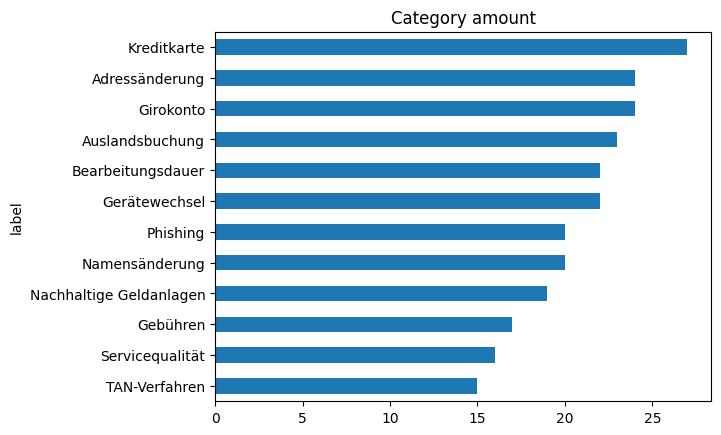

In [7]:
#samples per category
df['label'].value_counts(ascending=True).plot(kind='barh', title='Category amount')

### 1.2. Data Overview/ Content length statistics

label
TAN-Verfahren              34.133333
Phishing                   31.550000
Gerätewechsel              29.681818
Auslandsbuchung            25.478261
Namensänderung             23.650000
Servicequalität            23.437500
Girokonto                  22.875000
Bearbeitungsdauer          21.318182
Gebühren                   20.764706
Kreditkarte                20.370370
Adressänderung             18.958333
Nachhaltige Geldanlagen    18.315789
Name: nwords, dtype: float64


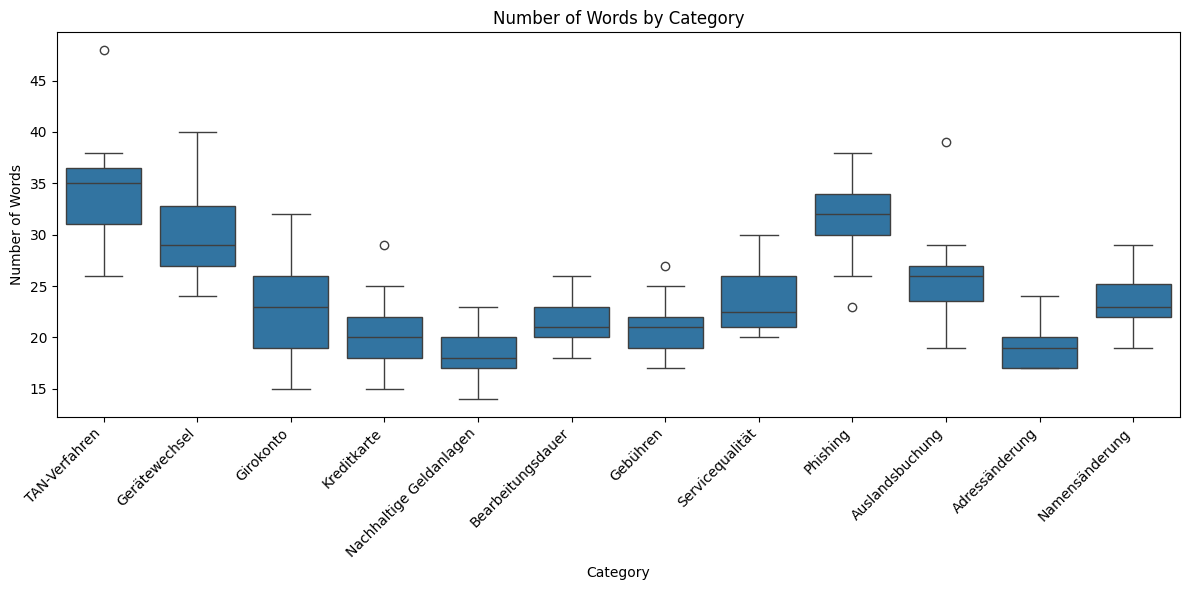

In [8]:
df['clean_nopunct'] = df['email_cleaned'].apply(lambda x: re.sub(r'[^\w\s]', '', x))

# number of words without punct
df['nwords'] = df['clean_nopunct'].str.split().apply(len)

avg_words_per_category = df.groupby('label')['nwords'].mean().sort_values(ascending=False)
print(avg_words_per_category)


plt.figure(figsize=(12, 6))
sns.boxplot(data=df, x='label', y='nwords')
plt.xticks(rotation=45, ha='right')
plt.title('Number of Words by Category')
plt.xlabel('Category')
plt.ylabel('Number of Words')
plt.tight_layout()
plt.show()

### 1.3. TF-IDF

Top 5 words & Wordcloud

In [9]:
tfidf = TfidfVectorizer(
    stop_words=enhanced_stopwords,
    max_features=10000,
    ngram_range=(1, 2),
    min_df=3,
    lowercase=True
)

X_tfidf = tfidf.fit_transform(df['email_cleaned'])
feature_names = tfidf.get_feature_names_out()

unique_labels = df['label'].unique()
top_n = 5

# Prepare plots
fig, axes = plt.subplots(4, 3, figsize=(18, 14))
axes = axes.flatten()

for idx, label in enumerate(unique_labels):
    # Filter samples of the current label
    label_indices = df[df['label'] == label].index
    X_label = X_tfidf[label_indices]

    # Calculate mean TF-IDF score for each term
    mean_tfidf = X_label.mean(axis=0).A1
    tfidf_scores = dict(zip(feature_names, mean_tfidf))

    # Print top-n words
    top_indices = mean_tfidf.argsort()[::-1][:top_n]
    top_words = [feature_names[i] for i in top_indices]
    print(f"Top {top_n} terms for category '{label}':")
    print(top_words)
    print()

    # Word cloud (only non-zero scores)
    tfidf_scores = {k: v for k, v in tfidf_scores.items() if v > 0}
    wordcloud = WordCloud(
        width=800,
        height=400,
        background_color='white'
    ).generate_from_frequencies(tfidf_scores)

    axes[idx].imshow(wordcloud, interpolation='bilinear')
    axes[idx].set_title(label, fontsize=14)
    axes[idx].axis('off')

for ax in axes[len(unique_labels):]:
    ax.axis('off')

plt.tight_layout()
plt.show()

Output hidden; open in https://colab.research.google.com to view.

### 1.4. SBERT

In [10]:
#SBERT embeddings
sbert = SentenceTransformer('distiluse-base-multilingual-cased-v2')
X_sbert = sbert.encode(df["email_cleaned"].tolist(), show_progress_bar=True)

# Reduce SBERT embeddings to 2D
reducer = umap.UMAP(n_neighbors=15, min_dist=0.1, random_state=42)
X_umap = reducer.fit_transform(X_sbert)


/usr/local/lib/python3.11/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


modules.json:   0%|          | 0.00/341 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/122 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

...

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/114 [00:00<?, ?B/s]

2_Dense/model.safetensors:   0%|          | 0.00/1.58M [00:00<?, ?B/s]

Batches:   0%|          | 0/8 [00:00<?, ?it/s]

/usr/local/lib/python3.11/dist-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


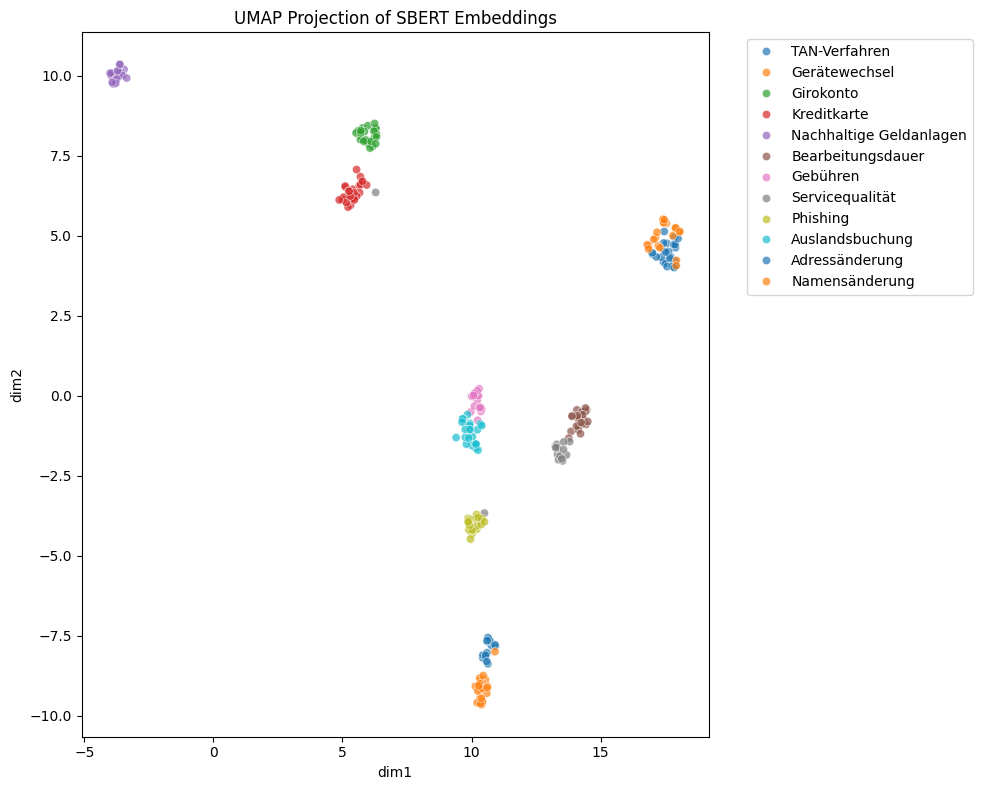

(249, 512)


In [11]:
# plotting UMAP
embed_df = pd.DataFrame(X_umap, columns=["dim1", "dim2"])
embed_df["label"] = df["label"]


plt.figure(figsize=(10, 8))
sns.scatterplot(data=embed_df, x="dim1", y="dim2", hue="label", palette="tab10", alpha=0.7)
plt.title("UMAP Projection of SBERT Embeddings")
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

print(X_sbert.shape)

# 2. EDA


### 2.1. Wordcloud
(According to word frequency)

In [12]:
# Generate word clouds for each label
fig, axes = plt.subplots(4, 3, figsize=(18, 14))
axes = axes.flatten()

for idx, label in enumerate(df['label'].unique()):
    # Filter emails by category,
    text = ' '.join(df[df['label'] == label]['email_cleaned'].tolist())

    # Create word cloud
    wordcloud = WordCloud(
        width=800,
        height=400,
        background_color='white',
        stopwords=set(enhanced_stopwords)
    ).generate(text)

    # Plot
    axes[idx].imshow(wordcloud, interpolation='bilinear')
    axes[idx].set_title(label, fontsize=14)
    axes[idx].axis('off')

# Remove any unused subplots
for ax in axes[len(df['label'].unique()):]:
    ax.axis('off')

plt.tight_layout()
plt.show()

Output hidden; open in https://colab.research.google.com to view.

### 2.2. Sentiment analysis

tokenizer_config.json:   0%|          | 0.00/161 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/665 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/436M [00:00<?, ?B/s]

Device set to use cuda:0
You seem to be using the pipelines sequentially on GPU. In order to maximize efficiency please use a dataset


label
Servicequalität           -1.000000
TAN-Verfahren             -1.000000
Phishing                  -0.950000
Gebühren                  -0.941176
Auslandsbuchung           -0.869565
Adressänderung            -0.750000
Gerätewechsel             -0.681818
Bearbeitungsdauer         -0.681818
Namensänderung            -0.550000
Girokonto                 -0.416667
Kreditkarte               -0.296296
Nachhaltige Geldanlagen   -0.052632
Name: sentiment, dtype: float64


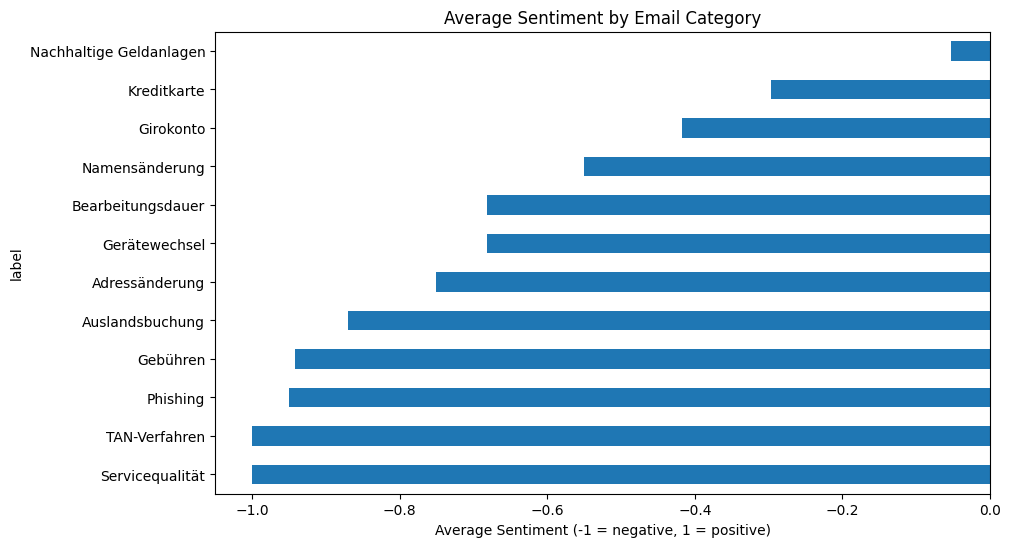

In [13]:
# model and tokenizer
model_name = "oliverguhr/german-sentiment-bert"
tokenizer = AutoTokenizer.from_pretrained(model_name)
model = AutoModelForSequenceClassification.from_pretrained(model_name)

# pipeline
sentiment_pipeline = pipeline("sentiment-analysis", model=model, tokenizer=tokenizer)

def get_sentiment_score(text):
    try:
        result = sentiment_pipeline(text[:512])[0]
        label = result["label"]
        score = {
            "positive": 1,
            "neutral": 0,
            "negative": -1
        }.get(label.lower(), 0)
        return score
    except:
        return None

df["sentiment"] = df["email_cleaned"].apply(get_sentiment_score)

# calculation of sentiment by categories
sentiment_by_label = df.groupby("label")["sentiment"].mean().sort_values()
print(sentiment_by_label)

# visualization
sentiment_by_label.plot(kind="barh", title="Average Sentiment by Email Category", figsize=(10, 6))
plt.xlabel("Average Sentiment (-1 = negative, 1 = positive)")
plt.show()


# 3. Models

3.1. TF-IDF + Logistics

In [14]:
#Vectorization & Tokenization

# Reproducibility
random.seed(42)
np.random.seed(42)

# Vectorization
tfidf_vectorizer = TfidfVectorizer(
    lowercase=True,
    max_features=5000
)

# Tokenization
X_tfidf = tfidf_vectorizer.fit_transform(df["email_cleaned"])
tokenizer = tfidf_vectorizer.build_tokenizer()

# Use the same tokenizer for stop words
vectorizer = TfidfVectorizer(
    lowercase=True,
    stop_words=[word for word in enhanced_stopwords if tokenizer(word)], # Filter stop words that the tokenizer can handle
    max_features=5000         # adjust to your setting
)
X_tfidf = vectorizer.fit_transform(df["email_cleaned"])


/usr/local/lib/python3.11/dist-packages/sklearn/feature_extraction/text.py:402: UserWarning: Your stop_words may be inconsistent with your preprocessing. Tokenizing the stop words generated tokens ['becker', 'ben', 'fischer', 'frau', 'herr', 'jonas', 'laura', 'max', 'mia', 'paul', 'schneider', 'schubert', 'wagner', 'weber'] not in stop_words.
  warnings.warn(


In [15]:
#Encoding & Split
#Encode labels
label_encoder = LabelEncoder()
y = label_encoder.fit_transform(df["label"])

#Split data
X_train_tfidf, X_test_tfidf, y_train, y_test = train_test_split(
    X_tfidf, y, test_size=0.2, stratify=y, random_state=42
)


/usr/local/lib/python3.11/dist-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(


Best C from CV: 200
        C  Mean Val LogLoss  Mean Train LogLoss  Mean Val Accuracy  \
0    0.01          2.473266            2.465101           0.944487   
1    0.10          2.372010            2.292954           0.949615   
2    1.00          1.715456            1.203166           0.949615   
3   10.00          0.913232            0.206509           0.949615   
4  100.00          0.538467            0.029521           0.949615   
5  200.00          0.469319            0.016591           0.949615   

   Mean Train Accuracy  
0                  1.0  
1                  1.0  
2                  1.0  
3                  1.0  
4                  1.0  
5                  1.0  


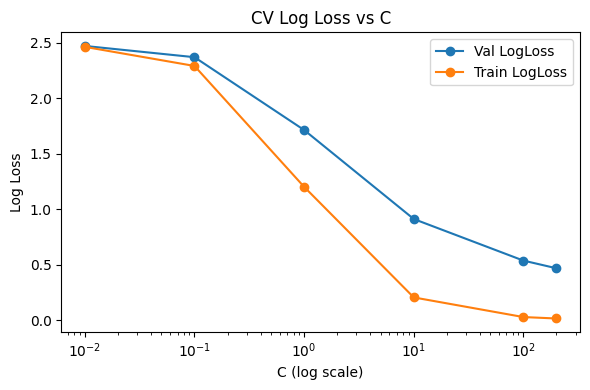

In [16]:
# Hyperparameter tuning
param_grid = {'C': [0.01, 0.1, 1, 10, 100, 200]}
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

base_clf = LogisticRegression(
    penalty='l2',
    multi_class='multinomial',
    solver='lbfgs',
    class_weight='balanced',
    max_iter=1000
)

scoring = {'neg_log_loss': 'neg_log_loss', 'accuracy': 'accuracy'}

grid_search = GridSearchCV(
    estimator=base_clf,
    param_grid=param_grid,
    scoring=scoring,
    refit='neg_log_loss',
    cv=cv,
    return_train_score=True,
    n_jobs=-1,
    verbose=0
)

grid_search.fit(X_train_tfidf, y_train)
cv_results = pd.DataFrame(grid_search.cv_results_)
best_C = grid_search.best_params_['C']
print(f"Best C from CV: {best_C}")

# CV summary
cv_summary = pd.DataFrame({
    'C': cv_results['param_C'].astype(float),
    'Mean Val LogLoss': -cv_results['mean_test_neg_log_loss'],
    'Mean Train LogLoss': -cv_results['mean_train_neg_log_loss'],
    'Mean Val Accuracy': cv_results['mean_test_accuracy'],
    'Mean Train Accuracy': cv_results['mean_train_accuracy']
}).sort_values('C')
print(cv_summary)

# Plot CV curves
plt.figure(figsize=(6,4))
plt.plot(cv_summary['C'], cv_summary['Mean Val LogLoss'], marker='o', label='Val LogLoss')
plt.plot(cv_summary['C'], cv_summary['Mean Train LogLoss'], marker='o', label='Train LogLoss')
plt.xscale('log')
plt.xlabel('C (log scale)')
plt.ylabel('Log Loss')
plt.title('CV Log Loss vs C')
plt.legend()
plt.tight_layout()
plt.show()


In [17]:
# Final model with C=100
final_model_tfidf = LogisticRegression(
    C=100,
    penalty='l2',
    multi_class='multinomial',
    solver='lbfgs',
    class_weight='balanced',
    max_iter=1000
).fit(X_train_tfidf, y_train)


/usr/local/lib/python3.11/dist-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(



Final Test Accuracy: 0.9600
Final Test Macro-F1: 0.9605
Final Test Log Loss: 0.4438

Classification Report:

                         precision    recall  f1-score   support

         Adressänderung     1.0000    1.0000    1.0000         5
        Auslandsbuchung     1.0000    1.0000    1.0000         5
      Bearbeitungsdauer     1.0000    0.7500    0.8571         4
               Gebühren     1.0000    1.0000    1.0000         3
          Gerätewechsel     1.0000    1.0000    1.0000         4
              Girokonto     1.0000    0.8000    0.8889         5
            Kreditkarte     0.8571    1.0000    0.9231         6
Nachhaltige Geldanlagen     1.0000    1.0000    1.0000         4
         Namensänderung     1.0000    1.0000    1.0000         4
               Phishing     1.0000    1.0000    1.0000         4
        Servicequalität     0.7500    1.0000    0.8571         3
          TAN-Verfahren     1.0000    1.0000    1.0000         3

               accuracy                    

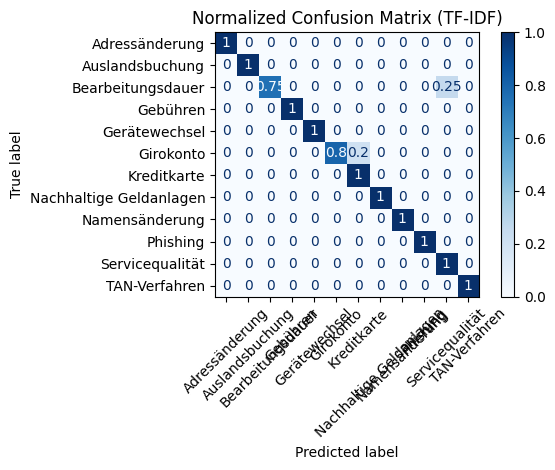


Top 5 predictive words for class 'Adressänderung':
name                 6.2808
adresse              3.9176
umgezogen            3.3678
anschrift            3.0914
julia                3.0005

Top 5 predictive words for class 'Auslandsbuchung':
abbuchung            4.4624
zahlung              4.1108
dollar               3.4562
bestellt             3.4388
anbieter             3.1582

Top 5 predictive words for class 'Bearbeitungsdauer':
warte                4.2708
lange                3.5008
rückmeldung          2.8431
warten               2.7963
anliegen             2.6845

Top 5 predictive words for class 'Gebühren':
gebühren             6.3518
kontoführungsgebühren 4.2738
erklären             3.2349
sind                 3.1306
höhe                 2.8629

Top 5 predictive words for class 'Gerätewechsel':
neues                4.5662
banking              4.1923
app                  3.3597
online               3.2801
smartphone           3.1937

Top 5 predictive words for class 'Girokon

In [18]:
#Evaluation & plotting
# Evaluation on test set
y_pred = final_model_tfidf.predict(X_test_tfidf)
y_proba = final_model_tfidf.predict_proba(X_test_tfidf)

print(f"\nFinal Test Accuracy: {accuracy_score(y_test, y_pred):.4f}")
print(f"Final Test Macro-F1: {f1_score(y_test, y_pred, average='macro'):.4f}")
print(f"Final Test Log Loss: {log_loss(y_test, y_proba):.4f}")

print("\nClassification Report:\n")
print(classification_report(
    y_test, y_pred,
    target_names=label_encoder.classes_,
    digits=4, zero_division=0
))

# Confusion Matrix
conf_matrix = confusion_matrix(y_test, y_pred, normalize='true')
disp = ConfusionMatrixDisplay(confusion_matrix=conf_matrix,
                              display_labels=label_encoder.classes_)
disp.plot(cmap="Blues", xticks_rotation=45)
plt.title("Normalized Confusion Matrix (TF-IDF)")
plt.tight_layout()
plt.show()

# Top 5 predictive words per class
feature_names = np.array(vectorizer.get_feature_names_out())
top_n = 5
coefs = final_model_tfidf.coef_

for idx, class_label in enumerate(label_encoder.classes_):
    top_indices = np.argsort(coefs[idx])[-top_n:][::-1]
    top_words = feature_names[top_indices]
    top_weights = coefs[idx, top_indices]

    print(f"\nTop {top_n} predictive words for class '{class_label}':")
    for word, weight in zip(top_words, top_weights):
        print(f"{word:<20} {weight:.4f}")

3.2. Embedded + Logistics

In [20]:
#Split
# Reproducibility
random.seed(42)
np.random.seed(42)

#Train-test split
X_train_sbert, X_test_sbert, y_train, y_test = train_test_split(
    X_sbert, y, stratify=y, test_size=0.2, random_state=42
)



Cross-Validation Summary (SBERT; refit by log loss):
     C  Mean Val LogLoss  Std Val LogLoss  Mean Val Accuracy  Mean Train LogLoss  Mean Train Accuracy
  0.01          2.458459         0.000294           0.974872            2.456091             0.994976
  0.10          2.237861         0.002423           0.979872            2.215424             0.994976
  1.00          1.163355         0.009853           0.984872            1.043562             1.000000
 10.00          0.327177         0.011842           0.995000            0.196123             1.000000
100.00          0.104425         0.010301           0.995000            0.030286             1.000000
200.00          0.078271         0.009887           0.995000            0.017259             1.000000
300.00          0.066151         0.009677           0.995000            0.012040             1.000000


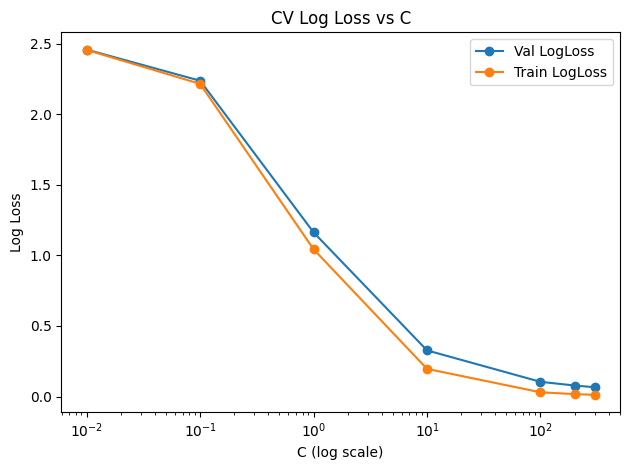

In [21]:
# Hyperparameter tuning
param_grid = {'C': [0.01, 0.1, 1, 10, 100,200,300]}
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

base_clf = LogisticRegression(
    penalty='l2',
    solver='lbfgs',
    class_weight='balanced',
    max_iter=1000
)

scoring = {'neg_log_loss': 'neg_log_loss', 'accuracy': 'accuracy'}

grid_search = GridSearchCV(
    estimator=base_clf,
    param_grid=param_grid,
    scoring=scoring,
    refit='neg_log_loss',
    cv=cv,
    return_train_score=True,
    n_jobs=-1,
    verbose=0
)
grid_search.fit(X_train_sbert, y_train)

best_C = grid_search.best_params_['C']
cv_results = pd.DataFrame(grid_search.cv_results_)

# CV summary
cv_summary = pd.DataFrame({
    'C': cv_results['param_C'].astype(float),
    'Mean Val LogLoss': -cv_results['mean_test_neg_log_loss'],
    'Std Val LogLoss': cv_results['std_test_neg_log_loss'],
    'Mean Val Accuracy': cv_results['mean_test_accuracy'],
    'Mean Train LogLoss': -cv_results['mean_train_neg_log_loss'],
    'Mean Train Accuracy': cv_results['mean_train_accuracy']
}).sort_values('C')
print("\nCross-Validation Summary (SBERT; refit by log loss):")
print(cv_summary.to_string(index=False))

# Plot CV curves
fig, ax = plt.subplots()
ax.plot(cv_summary['C'], cv_summary['Mean Val LogLoss'], marker='o', label='Val LogLoss')
ax.plot(cv_summary['C'], cv_summary['Mean Train LogLoss'], marker='o', label='Train LogLoss')
ax.set_xscale('log')
ax.set_title('CV Log Loss vs C')
ax.set_xlabel('C (log scale)')
ax.set_ylabel('Log Loss')
ax.legend()
plt.tight_layout()
plt.show()


In [22]:
#Final model - choose C = 100
final_model_sbert = LogisticRegression(
    C=100,
    penalty='l2',
    solver='lbfgs',
    class_weight='balanced',
    max_iter=1000
).fit(X_train_sbert, y_train)



Final Test Accuracy: 0.9800
Final Test Log Loss: 0.0997
Training Log Loss:  0.0266


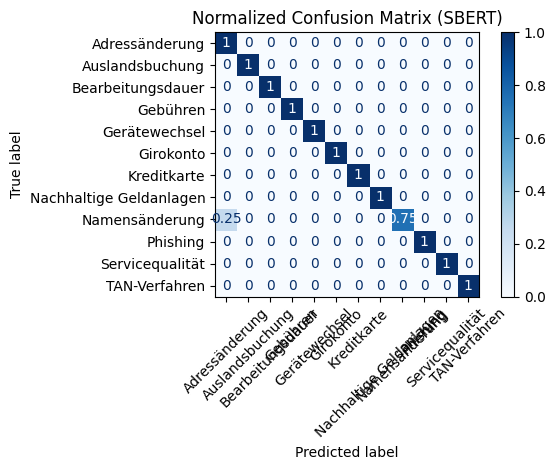


Classification Report (Per-Class Metrics):

                         precision  recall  f1-score  support
Adressänderung              0.8333  1.0000    0.9091     5.00
Auslandsbuchung             1.0000  1.0000    1.0000     5.00
Bearbeitungsdauer           1.0000  1.0000    1.0000     4.00
Gebühren                    1.0000  1.0000    1.0000     3.00
Gerätewechsel               1.0000  1.0000    1.0000     4.00
Girokonto                   1.0000  1.0000    1.0000     5.00
Kreditkarte                 1.0000  1.0000    1.0000     6.00
Nachhaltige Geldanlagen     1.0000  1.0000    1.0000     4.00
Namensänderung              1.0000  0.7500    0.8571     4.00
Phishing                    1.0000  1.0000    1.0000     4.00
Servicequalität             1.0000  1.0000    1.0000     3.00
TAN-Verfahren               1.0000  1.0000    1.0000     3.00
accuracy                    0.9800  0.9800    0.9800     0.98
macro avg                   0.9861  0.9792    0.9805    50.00
weighted avg             

In [23]:
#Evaluate on held-out test set
y_pred = final_model_sbert.predict(X_test_sbert)
y_proba = final_model_sbert.predict_proba(X_test_sbert)

test_accuracy = accuracy_score(y_test, y_pred)
test_logloss = log_loss(y_test, y_proba)
train_logloss = log_loss(y_train, final_model_sbert.predict_proba(X_train_sbert))

print(f"\nFinal Test Accuracy: {test_accuracy:.4f}")
print(f"Final Test Log Loss: {test_logloss:.4f}")
print(f"Training Log Loss:  {train_logloss:.4f}")

#Confusion Matrix (normalized)
conf_matrix = confusion_matrix(y_test, y_pred, normalize='true')
disp = ConfusionMatrixDisplay(confusion_matrix=conf_matrix,
                              display_labels=getattr(label_encoder, 'classes_', None))
disp.plot(cmap="Blues", xticks_rotation=45)
plt.title("Normalized Confusion Matrix (SBERT)")
plt.tight_layout()
plt.show()

#Classification Report
print("\nClassification Report (Per-Class Metrics):\n")
target_names = getattr(label_encoder, 'classes_', None)
report = classification_report(
    y_test, y_pred,
    target_names=target_names if target_names is not None else None,
    output_dict=True,
    zero_division=0
)
report_df = pd.DataFrame(report).transpose().round(4)
print(report_df)

# Top Embedding Dimensions per Class
top_n = 5
coef_df = pd.DataFrame(final_model_sbert.coef_,
                       index=(target_names if target_names is not None else range(final_model_sbert.coef_.shape[0])))

for label in coef_df.index:
    top = coef_df.loc[label].abs().nlargest(top_n)
    print(f"\nTop {top_n} influential embedding dimensions for class '{label}':")
    print(top)


SBERT — Gradient magnitude summary
Per-feature mean |grad| across classes:
     mean: 0.00002758
      std: 0.00000768
   median: 0.00002704
      p25: 0.00002275
      p75: 0.00003120
      p90: 0.00003623
      p95: 0.00004024
      p99: 0.00005347
      min: 0.00000914
      max: 0.00006499
        n: 512
  > 0.05: 0.0000% of features
  > 0.10: 0.0000% of features
  > 0.15: 0.0000% of features

All class-feature |grad| (flattened):
     mean: 0.00002758
      std: 0.00002267
   median: 0.00002247
      p25: 0.00001006
      p75: 0.00003903
      p90: 0.00005829
      p95: 0.00007008
      p99: 0.00010077
      min: 0.00000000
      max: 0.00018910
        n: 6144
  > 0.05: 0.0000% of entries
  > 0.10: 0.0000% of entries
  > 0.15: 0.0000% of entries

Top gradient dimensions (class, dim, |grad|, coef, activation stats):
                     1 | dim-419 | |grad|=0.00018910 | coef=3.6416 | mean|x|=0.0241, p95|x|=0.0654, >%0.10=0.00%, >%0.15=0.00%, >%0.20=0.00%
                     4 | 

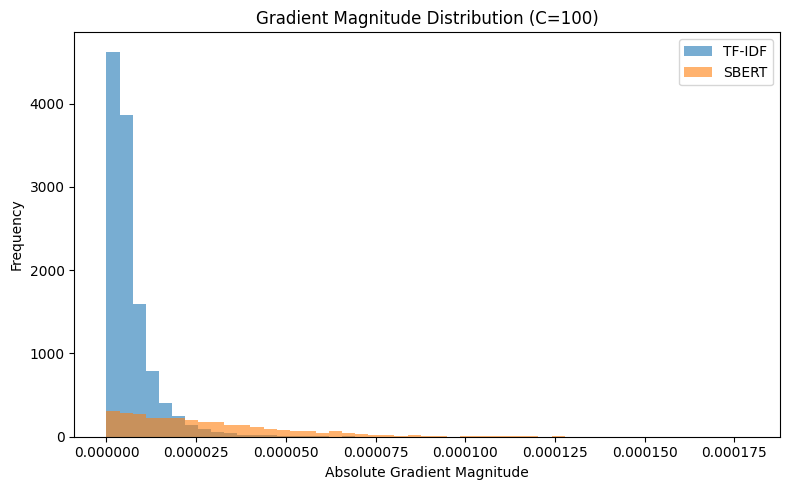

In [24]:
#Gradient update statistics
def compute_full_gradients(clf, X, y):

    probs = clf.predict_proba(X)   # (N, K) predicted probabilities
    N, K = probs.shape
    D = X.shape[1]
    Y = np.zeros((N, K))
    Y[np.arange(N), y] = 1.0

    grads = np.empty((K, D))
    # gradient for class j: (1/N) * X^T @ (p_j - y_j)
    err = probs - Y                         # (N, K)
    for j in range(K):
        grads[j, :] = (X.T @ err[:, j]) / N
    return grads, probs

def summarize_gradients(grads, name="SBERT", thresholds=(0.05, 0.10, 0.15)):

    abs_grads = np.abs(grads)
    per_feature_mean = abs_grads.mean(axis=0)  # (D,)
    flat = abs_grads.ravel()                   # (K*D,) gradient matrix for multinomial log-loss (per-class, per-dimension)

    def stats(arr):
        q25, q50, q75 = np.percentile(arr, [25, 50, 75])
        return {
            "mean": float(np.mean(arr)),
            "std": float(np.std(arr)),
            "median": float(q50),
            "p25": float(q25),
            "p75": float(q75),
            "p90": float(np.percentile(arr, 90)),
            "p95": float(np.percentile(arr, 95)),
            "p99": float(np.percentile(arr, 99)),
            "min": float(np.min(arr)),
            "max": float(np.max(arr)),
            "n": int(arr.size)
        }

    s_feat = stats(per_feature_mean)
    s_flat = stats(flat)

    print(f"\n{name} — Gradient magnitude summary")
    print("Per-feature mean |grad| across classes:")
    for k, v in s_feat.items():
        print(f"  {k:>7}: {v:.8f}" if isinstance(v, float) else f"  {k:>7}: {v}")
    for t in thresholds:
        print(f"  > {t:.2f}: {(per_feature_mean > t).mean()*100:.4f}% of features")

    print("\nAll class-feature |grad| (flattened):")
    for k, v in s_flat.items():
        print(f"  {k:>7}: {v:.8f}" if isinstance(v, float) else f"  {k:>7}: {v}")
    for t in thresholds:
        print(f"  > {t:.2f}: {(flat > t).mean()*100:.4f}% of entries")

    return {"per_feature": s_feat, "flat": s_flat}


#Top gradient dimensions
def top_gradient_dimensions(grads, X, clf, class_names=None, top_n=5, act_thresholds=(0.10, 0.15, 0.20)):

    abs_grads = np.abs(grads)                   # (K, D)
    K, D = abs_grads.shape
    # find top entries
    idx = np.dstack(np.unravel_index(np.argsort(abs_grads.ravel())[::-1][:top_n], (K, D)))[0]
    results = []
    print("\nTop gradient dimensions (class, dim, |grad|, coef, activation stats):")
    for (j, k) in idx:
        g = abs_grads[j, k]
        coef = clf.coef_[j, k]
        # activation profile for dimension k
        xk = X[:, k]
        mean_abs = float(np.mean(np.abs(xk)))
        p95_abs = float(np.percentile(np.abs(xk), 95))
        shares = {thr: float((np.abs(xk) > thr).mean()*100) for thr in act_thresholds}
        cname = class_names[j] if class_names is not None else f"class_{j}"
        print(f"  {cname:>20} | dim-{k:>3} | |grad|={g:.8f} | coef={coef:.4f} | "
              f"mean|x|={mean_abs:.4f}, p95|x|={p95_abs:.4f}, " +
              ", ".join([f">%{thr:.2f}={shares[thr]:.2f}%" for thr in act_thresholds]))
        results.append({
            "class_index": int(j),
            "class_name": cname,
            "dim": int(k),
            "abs_grad": float(g),
            "coef": float(coef),
            "mean_abs_x": mean_abs,
            "p95_abs_x": p95_abs,
            "shares_above": shares
        })
    return results

grads_tfidf, probs_tfidf = compute_full_gradients(final_model_tfidf, X_train_tfidf, y_train)
grads_sbert, probs_sbert = compute_full_gradients(final_model_sbert, X_train_sbert, y_train)
summ_sbert = summarize_gradients(grads_sbert, name="SBERT", thresholds=(0.05, 0.10, 0.15))
top_sbert = top_gradient_dimensions(
    grads_sbert,
    X_train_sbert,
    final_model_sbert,
    class_names=getattr(final_model_sbert, "classes_", None),  # replace with your label names list if available
    top_n=8,
    act_thresholds=(0.10, 0.15, 0.20)
)

#Overlay histogram
bins = np.linspace(0, max(grads_tfidf.max(), grads_sbert.max()), 50)
plt.figure(figsize=(8, 5))
plt.hist(grads_tfidf.ravel(), bins=bins, alpha=0.6, label='TF-IDF')
plt.hist(grads_sbert.ravel(), bins=bins, alpha=0.6, label='SBERT')
plt.xlabel("Absolute Gradient Magnitude")
plt.ylabel("Frequency")
plt.title("Gradient Magnitude Distribution (C=100)")
plt.legend()
plt.tight_layout()
plt.show()

3.3 Embedding + XG Boost

In [34]:
from scipy.sparse import issparse
import xgboost as xgb
from sklearn.model_selection import cross_validate

In [30]:
##Data preparation
#Reproductability
random.seed(42)
np.random.seed(42)

# Safety check: ensure shapes align
assert X_sbert.shape[0] == len(y), "Mismatch between X and y row counts."

# Dealing with sparse/ compressed sparse row
if issparse(X_sbert):
    X_sbert = X_sbert.tocsr()

#Train/test split
X_train, X_test, y_train, y_test = train_test_split(
    X_sbert, y, stratify=y, test_size=0.2, random_state=42)



Cross-Validation Summary (lower log loss is better):

 reg_lambda  CV Mean Log Loss  CV Std Log Loss  CV Mean Accuracy
      10.00            0.3681           0.0315            0.9446
       1.00            0.3823           0.0400            0.9296
       0.10            0.3917           0.0366            0.9145
       0.01            0.3946           0.0356            0.9245
      50.00            0.5425           0.0362            0.9295
     100.00            0.7611           0.0419            0.9145


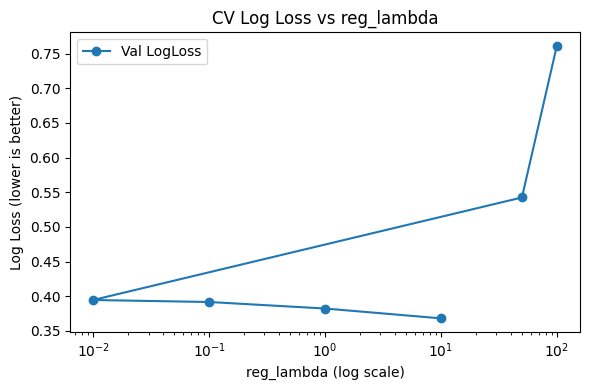

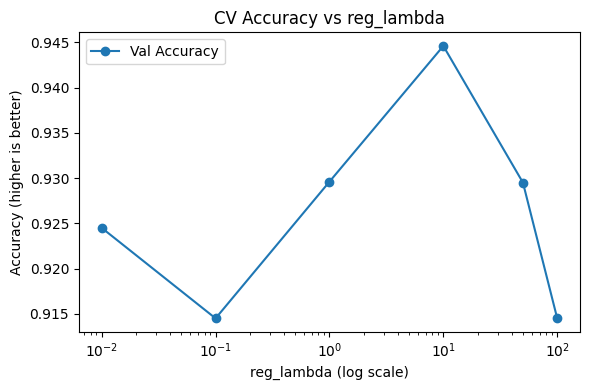


Selected reg_lambda = 10.0 (best CV log-loss = 0.3681)


In [35]:
# Cross-validation for different reg_lambda
lambda_values = [0.01, 0.1, 1, 10, 50, 100] #punishment candidates
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# Base params with enhanced settings
base_params = dict(
    objective="multi:softprob",
    num_class=len(label_encoder.classes_),
    eval_metric="mlogloss",
    max_depth=6,
    learning_rate=0.1,
    reg_alpha=0,
    subsample=0.8,
    colsample_bytree=0.8,
    n_estimators=400,
    random_state=42,
    tree_method="gpu_hist",
    gpu_id=0,
    verbosity=0,
)

logloss_summary = []
for lam in lambda_values:
    model = xgb.XGBClassifier(**base_params, reg_lambda=lam)

    scores = cross_validate(
        model, X_train, y_train, cv=cv,
        scoring={"neg_log_loss": "neg_log_loss", "accuracy": "accuracy"},
        n_jobs=1, return_train_score=False
    )

    mean_logloss = -np.mean(scores["test_neg_log_loss"])
    std_logloss = np.std(-scores["test_neg_log_loss"])
    mean_acc = np.mean(scores["test_accuracy"])

    logloss_summary.append({
        "reg_lambda": lam,
        "CV Mean Log Loss": round(mean_logloss, 4),
        "CV Std Log Loss": round(std_logloss, 4),
        "CV Mean Accuracy": round(mean_acc, 4),
    })

logloss_df = pd.DataFrame(logloss_summary).sort_values("CV Mean Log Loss")
print("\nCross-Validation Summary (lower log loss is better):\n")
print(logloss_df.to_string(index=False))

# CV curves
plt.figure(figsize=(6,4))
plt.plot(logloss_df["reg_lambda"], logloss_df["CV Mean Log Loss"], marker="o", label="Val LogLoss")
plt.xscale("log")
plt.xlabel("reg_lambda (log scale)")
plt.ylabel("Log Loss (lower is better)")
plt.title("CV Log Loss vs reg_lambda")
plt.legend()
plt.tight_layout()
plt.show()

plt.figure(figsize=(6,4))
# Reindex by original order for a smooth curve
acc_plot_df = pd.DataFrame(logloss_summary).sort_values("reg_lambda")
plt.plot(acc_plot_df["reg_lambda"], acc_plot_df["CV Mean Accuracy"], marker="o", label="Val Accuracy")
plt.xscale("log")
plt.xlabel("reg_lambda (log scale)")
plt.ylabel("Accuracy (higher is better)")
plt.title("CV Accuracy vs reg_lambda")
plt.legend()
plt.tight_layout()
plt.show()

#Choose the best lambda
best_row = logloss_df.iloc[0]
final_lambda = float(best_row["reg_lambda"])
print(f"\nSelected reg_lambda = {final_lambda} (best CV log-loss = {best_row['CV Mean Log Loss']})")


In [36]:
#Final model training
final_model = xgb.XGBClassifier(**base_params, reg_lambda=final_lambda)
final_model.fit(X_train, y_train)


XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=0.8, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='mlogloss',
              feature_types=None, feature_weights=None, gamma=None, gpu_id=0,
              grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=0.1, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=6, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=400, n_jobs=None, ...)


Final Test Accuracy: 0.9600
Final Test Log Loss: 0.2821
Training Log Loss: 0.0353


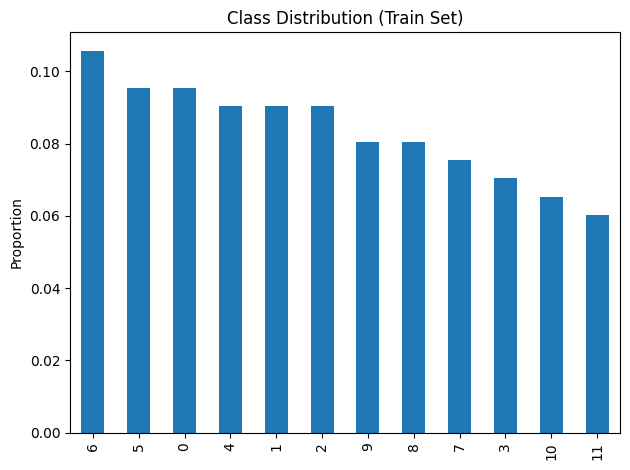

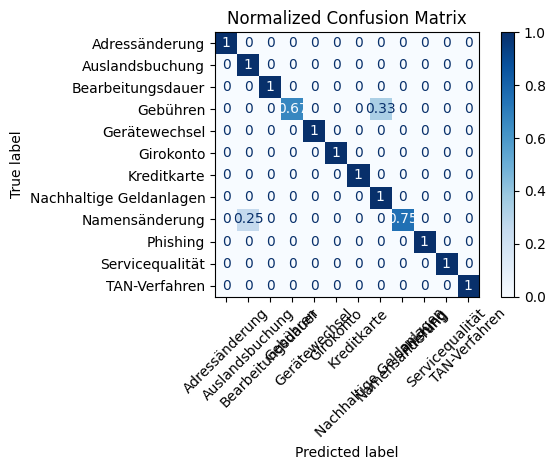


Classification Report (Per-Class Metrics):

                         precision    recall  f1-score   support

         Adressänderung     1.0000    1.0000    1.0000         5
        Auslandsbuchung     0.8333    1.0000    0.9091         5
      Bearbeitungsdauer     1.0000    1.0000    1.0000         4
               Gebühren     1.0000    0.6667    0.8000         3
          Gerätewechsel     1.0000    1.0000    1.0000         4
              Girokonto     1.0000    1.0000    1.0000         5
            Kreditkarte     1.0000    1.0000    1.0000         6
Nachhaltige Geldanlagen     0.8000    1.0000    0.8889         4
         Namensänderung     1.0000    0.7500    0.8571         4
               Phishing     1.0000    1.0000    1.0000         4
        Servicequalität     1.0000    1.0000    1.0000         3
          TAN-Verfahren     1.0000    1.0000    1.0000         3

               accuracy                         0.9600        50
              macro avg     0.9694    0.951

<Figure size 1000x600 with 0 Axes>

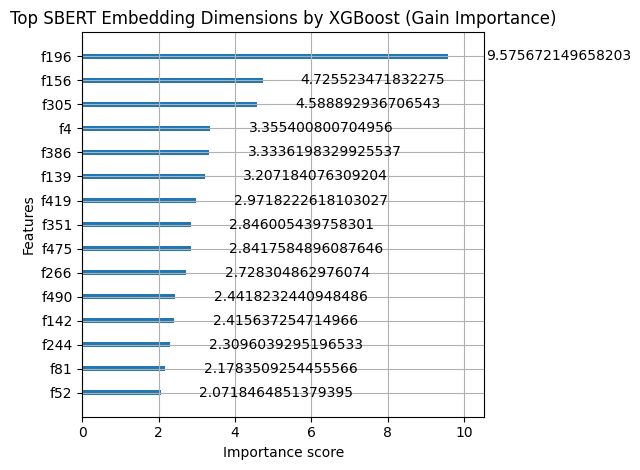

In [37]:
#Evaluation
#Evaluation- Test
y_pred = final_model.predict(X_test)
y_proba = final_model.predict_proba(X_test)

test_accuracy = accuracy_score(y_test, y_pred)
test_logloss = log_loss(y_test, y_proba)
train_logloss = log_loss(y_train, final_model.predict_proba(X_train))

print(f"\nFinal Test Accuracy: {test_accuracy:.4f}")
print(f"Final Test Log Loss: {test_logloss:.4f}")
print(f"Training Log Loss: {train_logloss:.4f}")

# 6. Class distribution-Train for balance check
pd.Series(y_train).value_counts(normalize=True).plot(
    kind="bar", title="Class Distribution (Train Set)"
)
plt.ylabel("Proportion")
plt.tight_layout()
plt.show()

# Confusion Matrix
conf_matrix = confusion_matrix(y_test, y_pred, normalize='true')
disp = ConfusionMatrixDisplay(conf_matrix, display_labels=label_encoder.classes_)
disp.plot(cmap="Blues", xticks_rotation=45)
plt.title("Normalized Confusion Matrix")
plt.tight_layout()
plt.show()

# Classification Report
print("\nClassification Report (Per-Class Metrics):\n")
# Convert class names to strings explicitly
target_names_str = [str(name) for name in label_encoder.classes_]
print(classification_report(y_test, y_pred, target_names=target_names_str, zero_division=0, digits=4))

#Feature Importance
plt.figure(figsize=(10, 6))
xgb.plot_importance(final_model, importance_type='gain', max_num_features=15)
plt.title("Top SBERT Embedding Dimensions by XGBoost (Gain Importance)")
plt.tight_layout()
plt.show()

Save final model

In [38]:
import joblib

In [39]:
#save embedded logisitics regression model
joblib.dump(final_model_sbert, "final_model_sbert.pkl")
joblib.dump(sbert, "sbert_encoder.pkl")

['sbert_encoder.pkl']